## Lab Exercise 3

### Student Survey: Simple Linear Regression using Scikit Learn, OLS, and Parameter Saving

### Aim 

1. To collect real-world student survey data using Google Forms, preprocess and clean the dataset, perform
2. Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary
3. Least Squares (OLS) formulas, compare both approaches, and save the learned model parameters.

### Problem Statement
Using the dataset collected from the class survey form, perform Simple Linear Regression analysis to
determine whether:
1. CIA percentage can predict GPA
2. Attendance percentage can predict GPA

You are required to perform regression in two different ways:
1. Using Scikit learn Linear Regression
2. Manually using the mathematical equations of slope and intercept derived from Ordinary Least
Squares (OLS)

Finally, compare the outputs obtained from both methods and save the learned model parameters.

In [94]:
import pandas as pd

### Part A: Data Collection and Preprocessing

**1. Load the dataset using Pandas**

**2. Display the first 5 rows**

In [95]:
data = pd.read_csv('Department Awareness.csv')
data.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),MedianSalaryOfPlacedStudents,Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),LastSemesterCIA,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6-22-2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6-22-2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6-22-2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6-22-2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6-22-2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


**3. Check dataset dimensions**

In [96]:
print('DATASET DIMENSIONS','\nnumber of rows:', data.shape[0], '\nnumber of columns:', data.shape[1])

DATASET DIMENSIONS 
number of rows: 54 
number of columns: 15


**Additional processing**

1. Since the column names are verybig and will be difficult to query, we have replaced them with shorter names. 

In [97]:
data.rename(columns={
    'Registeration Number': 'RegNo',
    'Job role that you are interested in\n': 'InterestedJobRole',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'MinSalaryOfPlacedStudents',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'MaxSalaryOfPlacedStudents',
    'Which is the highest paying company': 'HighestPayingCompany',
    'Rate your contribution towards extra curricular activities': 'ContributionToExtraCurricularActivities',
    'Rate your technical competencies': 'TechnicalCompetencies',
    'What are your package expectations (LPA)': 'PackageExpectations',
    'your GPA of last semester': 'LastSemesterGPA',
    'Your maximum attendance % till last semester': 'MaxAttendanceTillLastSemester',
    'Internships Interests': 'InternshipInterests'
}, inplace=True)

In [98]:
data.head()

,Timestamp,Registration Number,Email,InterestedJobRole,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,HighestPayingCompany,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterCIA,LastSemesterGPA,MaxAttendanceTillLastSemester,InternshipInterests
0,6-22-2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6-22-2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6-22-2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6-22-2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6-22-2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


Now, the column names are shorter and easy to include in the code. 

**4. Identify missing values**

In [99]:
data.isnull().sum()

Timestamp                                  0
Registration Number                        0
Email                                      0
InterestedJobRole                          0
MinSalaryOfPlacedStudents                  0
MaxSalaryOfPlacedStudents                  0
MedianSalaryOfPlacedStudents               0
HighestPayingCompany                       0
ContributionToExtraCurricularActivities    0
TechnicalCompetencies                      0
PackageExpectations                        0
LastSemesterCIA                            0
LastSemesterGPA                            0
MaxAttendanceTillLastSemester              0
InternshipInterests                        0
dtype: int64

There are no missing values in this dataset.

**6. Convert required columns into numerical datatype**

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Timestamp                                54 non-null     object
 1   Registration Number                      54 non-null     object
 2   Email                                    54 non-null     object
 3   InterestedJobRole                        54 non-null     object
 4   MinSalaryOfPlacedStudents                54 non-null     object
 5   MaxSalaryOfPlacedStudents                54 non-null     object
 6   MedianSalaryOfPlacedStudents             54 non-null     object
 7   HighestPayingCompany                     54 non-null     object
 8   ContributionToExtraCurricularActivities  54 non-null     int64 
 9   TechnicalCompetencies                    54 non-null     int64 
 10  PackageExpectations                      54 non-null     object


This tells us the datatype of each column in the dataset. 

In [101]:
num_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations',
    'LastSemesterGPA',
]

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [102]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Timestamp                                54 non-null     object 
 1   Registration Number                      54 non-null     object 
 2   Email                                    54 non-null     object 
 3   InterestedJobRole                        54 non-null     object 
 4   MinSalaryOfPlacedStudents                41 non-null     float64
 5   MaxSalaryOfPlacedStudents                36 non-null     float64
 6   MedianSalaryOfPlacedStudents             42 non-null     float64
 7   HighestPayingCompany                     54 non-null     object 
 8   ContributionToExtraCurricularActivities  54 non-null     int64  
 9   TechnicalCompetencies                    54 non-null     int64  
 10  PackageExpectations                      40 non-null

As we can see now, all columns with numerical values have been converted to numerical datatype float64.

**7. Remove duplicate records if present**

In [103]:
data[data.duplicated(keep=False)]

,Timestamp,Registration Number,Email,InterestedJobRole,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,HighestPayingCompany,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterCIA,LastSemesterGPA,MaxAttendanceTillLastSemester,InternshipInterests


There are no duplicates in this dataset.

**8. Generate statistical summary**

In [104]:
data.describe()

,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterGPA
count,4.100000e+01,3.600000e+01,4.200000e+01,54.000000,54.000000,4.000000e+01,53.000000
mean,5.171161e+04,7.167978e+04,1.726256e+05,3.592593,3.407407,8.501000e+04,5.313962
std,2.408715e+05,2.903905e+05,7.182451e+05,0.981307,0.835950,3.158599e+05,11.906827
min,2.000000e+00,8.000000e+00,5.000000e+00,2.000000,1.000000,5.000000e+00,2.900000
25%,4.000000e+00,1.200000e+01,6.300000e+00,3.000000,3.000000,8.000000e+00,3.370000
50%,4.500000e+00,1.200000e+01,7.000000e+00,4.000000,3.000000,1.000000e+01,3.500000
75%,6.000000e+00,1.775000e+01,9.000000e+00,4.000000,4.000000,1.225000e+01,3.700000
max,1.500000e+06,1.300000e+06,4.500000e+06,5.000000,5.000000,1.500000e+06,90.000000


In the Maximum Attendance column, there are some records with '%'. We need to remove it first.

In [105]:
import numpy as np
# Replace Option 1 with NaN
data['MaxAttendanceTillLastSemester'] = (
    data['MaxAttendanceTillLastSemester']
    .replace('Option 1', np.nan)
)

# Remove % signs
data['MaxAttendanceTillLastSemester'] = (
    data['MaxAttendanceTillLastSemester']
    .str.rstrip('%')
)

# Convert to numeric
data['MaxAttendanceTillLastSemester'] = pd.to_numeric(
    data['MaxAttendanceTillLastSemester'],
    errors='coerce'
)


In [113]:
# Remove % signs
data['LastSemesterCIA'] = (
    data['LastSemesterCIA']
    .str.rstrip('%')
)

# Convert to numeric
data['LastSemesterCIA'] = pd.to_numeric(
    data['LastSemesterCIA'],
    errors='coerce'
)

By looking at the data, we can see that there are a lot of NaN values in some of the numerical columns. These may have gone unnnoticed earlier as these columns had the datatype object. Since we changed it to numerical dataypes, we can see the error now. 
Since this dataset is very small, getting rid of the rows would mean removing the oppurtunity of getting accurate analysis. So, we will imput these values with median of their columns.

In [114]:
data.isna().sum()

Timestamp                                  0
Registration Number                        0
Email                                      0
InterestedJobRole                          0
MinSalaryOfPlacedStudents                  0
MaxSalaryOfPlacedStudents                  0
MedianSalaryOfPlacedStudents               0
HighestPayingCompany                       0
ContributionToExtraCurricularActivities    0
TechnicalCompetencies                      0
PackageExpectations                        0
LastSemesterCIA                            1
LastSemesterGPA                            0
MaxAttendanceTillLastSemester              0
InternshipInterests                        0
dtype: int64

In [116]:
num_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations',
    'LastSemesterGPA',
    'MaxAttendanceTillLastSemester',
    'LastSemesterCIA'
]

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [117]:
data.isna().sum()

Timestamp                                  0
Registration Number                        0
Email                                      0
InterestedJobRole                          0
MinSalaryOfPlacedStudents                  0
MaxSalaryOfPlacedStudents                  0
MedianSalaryOfPlacedStudents               0
HighestPayingCompany                       0
ContributionToExtraCurricularActivities    0
TechnicalCompetencies                      0
PackageExpectations                        0
LastSemesterCIA                            0
LastSemesterGPA                            0
MaxAttendanceTillLastSemester              0
InternshipInterests                        0
dtype: int64

As we can see, there are no more missing or NaN values in the dataset.

**Outlier Detection**

In [131]:
# Detect outliers using IQR
Q1 = data['LastSemesterCIA'].quantile(0.25)
Q3 = data['LastSemesterCIA'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = data[
    (data['LastSemesterCIA'] < lower_bound) |
    (data['LastSemesterCIA'] > upper_bound)
]

print("Number of outliers:", len(outliers))

# Winsorization (capping)
data['LastSemesterCIA'] = data['LastSemesterCIA'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Outliers treated using Winsorization.")

Number of outliers: 2
Outliers treated using Winsorization.


In [132]:
from sklearn.preprocessing import StandardScaler

# Numerical columns
num_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations',
    'LastSemesterCIA',
    'LastSemesterGPA',
    'MaxAttendanceTillLastSemester'
]

scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

data.head()

,Timestamp,Registration Number,Email,InterestedJobRole,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,HighestPayingCompany,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterCIA,LastSemesterGPA,MaxAttendanceTillLastSemester,InternshipInterests
0,6-22-2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,-0.188309,-0.202267,-0.213124,Deolite,2,2,-0.232345,0.650683,-0.174587,0.075002,Industry
1,6-22-2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,-0.188307,-0.202267,-0.213127,Deolite,4,3,-0.232334,-1.197873,-0.178010,0.075002,Industry
2,6-22-2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,-0.188300,-0.202246,-0.213126,DE Shaw,5,5,-0.232323,0.930344,-0.143784,0.075002,Industry
3,6-22-2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,-0.188307,-0.202267,-0.213127,DE Shaw,3,4,-0.232345,-0.467959,-0.178010,-0.259349,Industry
4,6-22-2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,-0.188290,-0.202267,-0.213122,EY,5,3,-0.232334,-0.747619,-0.160897,-1.819653,Industry


### Part B: Simple Linear Regression using Scikit-learn
Perform the following:
1. Split the dataset into training and testing sets
2. Train the model using LinearRegression from Scikit learn
3. Obtain:
    * Slope
    * Intercept
4. Predict output values using the trained mod

**Independent Variable (X): CIA Percentage**

**Dependent Variable (Y): GPA**

In [135]:
# Independent variable (X)
X = data[['LastSemesterCIA']]

# Dependent variable (Y)
y = data['LastSemesterGPA']

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [137]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [138]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.2121187347582778
Intercept: 0.030521335278429988


In [139]:
y_pred = model.predict(X_test)

In [140]:

results = pd.DataFrame({
    'Actual GPA': y_test.values,
    'Predicted GPA': y_pred
})

results.head(10)

,Actual GPA,Predicted GPA
0,-0.130949,0.168543
1,-0.131804,0.168543
2,-0.155763,-0.024251
3,-0.154051,-0.068741
4,-0.195123,0.079562
5,-0.152340,-0.068741
6,-0.203680,-0.187384
7,0.215596,0.405828
8,-0.178010,-0.068741
9,-0.143784,0.079562


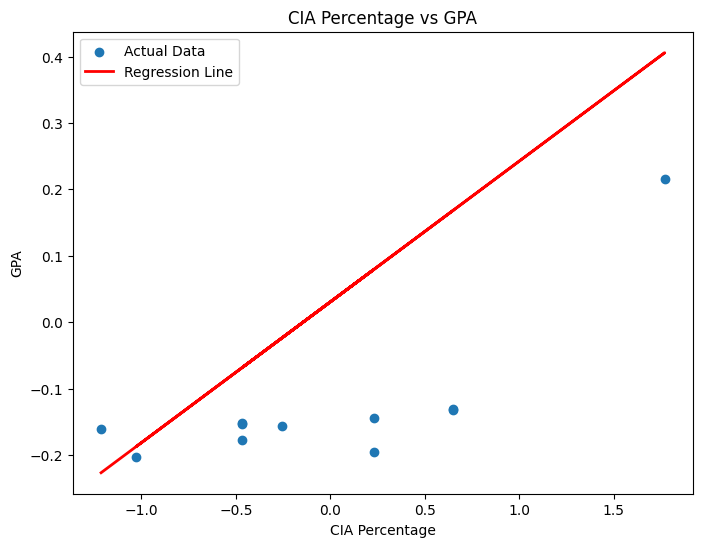

In [141]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.title('CIA Percentage vs GPA')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.legend()

plt.show()

In [142]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: -1.903524994077948
MAE: 0.16182032621419465
RMSE: 0.1881832097681211


In [143]:
print(data[['LastSemesterCIA','LastSemesterGPA']].corr())

                 LastSemesterCIA  LastSemesterGPA
LastSemesterCIA         1.000000         0.198394
LastSemesterGPA         0.198394         1.000000


The linear regression model shows a weak relationship between CIA percentage and GPA. The negative R² score (-1.90) indicates that the model performs worse than predicting the average GPA for all students, suggesting that CIA percentage alone is not sufficient to explain students' GPA. This is likely because GPA is influenced by several additional factors such as end-semester examinations, assignments, practical work, and overall academic performance. Therefore, a multiple linear regression model using more predictor variables would be more appropriate for accurately predicting GPA.

**Independent Variable (X): Attendance Percentage**

**Dependent Variable (Y): GPA**

In [144]:
# Independent variable (X)
X = data[['MaxAttendanceTillLastSemester']]

# Dependent variable (Y)
y = data['LastSemesterGPA']

In [145]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [146]:

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.3039235856895383
Intercept: 0.03306697597926565


In [148]:
y_pred = model.predict(X_test)

In [149]:
results = pd.DataFrame({
    'Actual GPA': y_test.values,
    'Predicted GPA': y_pred
})

results.head(10)

,Actual GPA,Predicted GPA
0,-0.130949,-0.091345
1,-0.131804,-0.385357
2,-0.155763,-0.294579
3,-0.154051,-0.226834
4,-0.195123,0.247379
5,-0.152340,0.450613
6,-0.203680,0.179634
7,0.215596,0.518358
8,-0.178010,0.111889
9,-0.143784,-0.023600


In [150]:
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: -6.391842277063469
MAE: 0.24690192578337075
RMSE: 0.3002578933514625


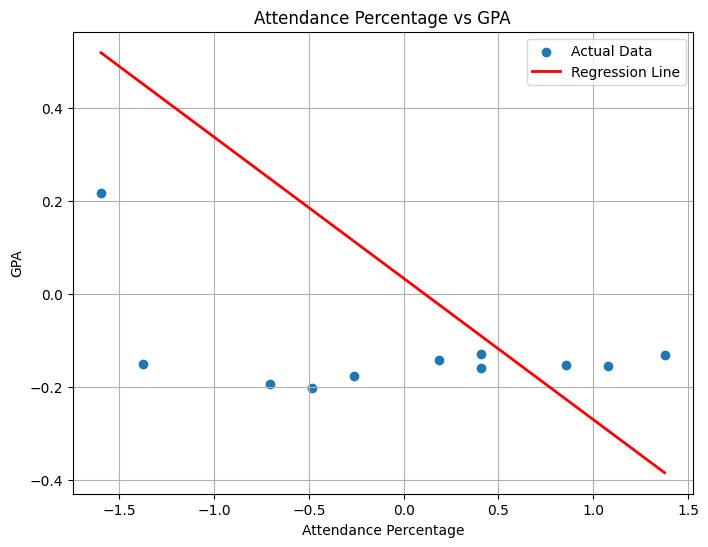

In [151]:
# Sort X values for a clean regression line
sorted_idx = np.argsort(X_test['MaxAttendanceTillLastSemester'].values)

X_sorted = X_test.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, label='Actual Data')
plt.plot(
    X_sorted,
    y_pred_sorted,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title('Attendance Percentage vs GPA')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.legend()
plt.grid(True)

plt.show()

The linear regression model indicates a very weak relationship between attendance percentage and GPA. The negative R² score (-6.39) shows that attendance alone is not a reliable predictor of academic performance in this dataset. The regression line suggests a negative trend; however, this is likely due to the small sample size, data variability, and the influence of a few observations rather than a genuine relationship. Therefore, attendance percentage by itself is insufficient for accurately predicting students' GPA.

**Independent Variable (X): CIA Percentage** 

**Dependent Variable (Y): GPA**

In [168]:
# X and Y
x = data['LastSemesterCIA']
y = data['LastSemesterGPA']

# Means
x_mean = x.mean()
y_mean = y.mean()

# Slope (m)
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

# Intercept (b)
b = y_mean - (m * x_mean)

print("Mean of X:", x_mean)
print("Mean of Y:", y_mean)
print("Slope (m):", m)
print("Intercept (b):", b)

print(f"\nRegression Equation:")
print(f"ŷ = {m:.4f}x + {b:.4f}")

Mean of X: 1.46384961765391e-15
Mean of Y: -7.015992725061753e-17
Slope (m): 0.1983937054544085
Intercept (b): -3.6057847712499585e-16

Regression Equation:
ŷ = 0.1984x + -0.0000


In [153]:
# Predicted values
y_pred = m * x + b

# Display first few predictions
results = data[['LastSemesterCIA', 'LastSemesterGPA']].copy()
results['Predicted_GPA'] = y_pred

results.head()

,LastSemesterCIA,LastSemesterGPA,Predicted_GPA
0,0.650683,-0.174587,0.129091
1,-1.197873,-0.178010,-0.237650
2,0.930344,-0.143784,0.184574
3,-0.467959,-0.178010,-0.092840
4,-0.747619,-0.160897,-0.148323


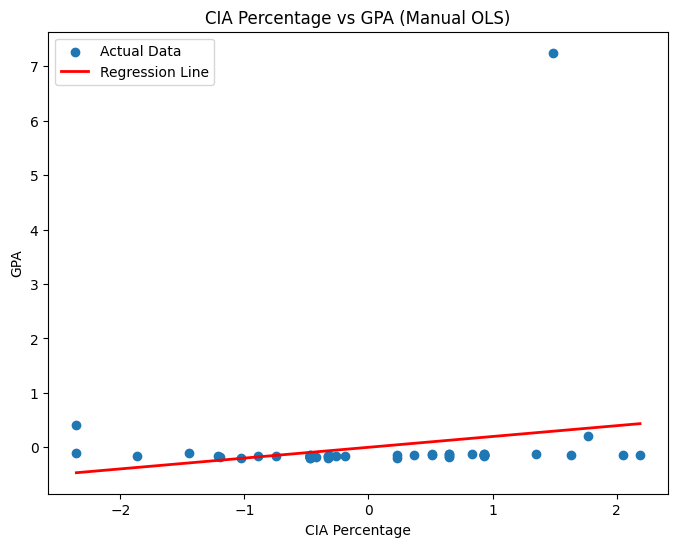

In [154]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, label='Actual Data')

# Sort for a proper line
idx = np.argsort(x)

plt.plot(
    x.iloc[idx],
    y_pred.iloc[idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title("CIA Percentage vs GPA (Manual OLS)")
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.legend()

plt.show()

**Independent Variable (X): Attendance Percentage**

 **Dependent Variable (Y): GPA**

In [158]:
# X and Y
x = data['MaxAttendanceTillLastSemester']
y = data['LastSemesterGPA']

# Means
x_mean = x.mean()
y_mean = y.mean()

# Slope
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

# Intercept
b = y_mean - (m * x_mean)

print("Mean of X:", x_mean)
print("Mean of Y:", y_mean)
print("Slope (m):", m)
print("Intercept (b):", b)

print(f"\nRegression Equation:")
print(f"ŷ = {m:.4f}x + {b:.4f}")

Mean of X: 7.082811703395675e-16
Mean of Y: -7.015992725061753e-17
Slope (m): -0.2598911901007823
Intercept (b): 1.139161090349076e-16

Regression Equation:
ŷ = -0.2599x + 0.0000


In [159]:
# Predicted values
y_pred = m * x + b

results = data[['MaxAttendanceTillLastSemester', 'LastSemesterGPA']].copy()
results['Predicted_GPA'] = y_pred

results.head()

,MaxAttendanceTillLastSemester,LastSemesterGPA,Predicted_GPA
0,0.075002,-0.174587,-0.019492
1,0.075002,-0.178010,-0.019492
2,0.075002,-0.143784,-0.019492
3,-0.259349,-0.178010,0.067403
4,-1.819653,-0.160897,0.472912


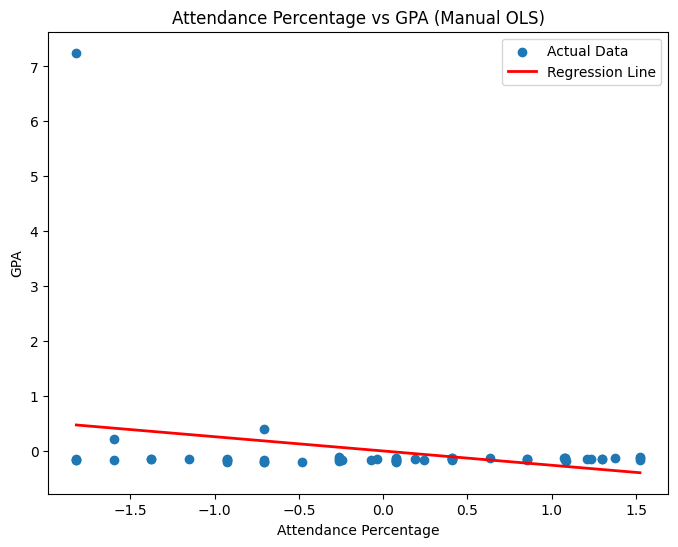

In [160]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, label='Actual Data')

idx = np.argsort(x)

plt.plot(
    x.iloc[idx],
    y_pred.iloc[idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title("Attendance Percentage vs GPA (Manual OLS)")
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.legend()

plt.show()

### Parameter Saving using Pickle


In [169]:
# Get slope and intercept from the trained model
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.3039235856895383
Intercept: 0.03306697597926565


In [170]:
import pickle

# Store parameters in a dictionary
parameters = {
    "slope": slope,
    "intercept": intercept
}

# Save to pickle file
with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

print("Parameters saved successfully!")

Parameters saved successfully!


In [171]:
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_parameters = pickle.load(file)

print(loaded_parameters)

{'slope': np.float64(-0.3039235856895383), 'intercept': np.float64(0.03306697597926565)}


In [172]:
loaded_slope = loaded_parameters["slope"]
loaded_intercept = loaded_parameters["intercept"]

# Example: predict GPA for CIA = 85
cia = 85

predicted_gpa = loaded_slope * cia + loaded_intercept

print("Predicted GPA:", predicted_gpa)

Predicted GPA: -25.80043780763149



The trained Linear Regression model learns two parameters:
- **Slope (Coefficient):** Represents the change in GPA for a one-unit increase in the independent variable.
- **Intercept:** Represents the predicted GPA when the independent variable is zero.

These parameters were saved into a Pickle file named **linear_regression_weights.pkl**. The file was then loaded successfully, and the stored parameters were used to make predictions without retraining the model. This demonstrates how a trained model can be reused efficiently in future applications.